# CIC-IDS2018 — Profesyonel EDA

Master sample: `data/eda_samples/cloud_master.parquet` (tum gunlerden stratified orneklem).

Once: `python scripts/build_eda_master_samples.py --domain cloud`


Uyari: 59 satir bozuk etiket (Label) atildi.

CIC-IDS2018 Profesyonel EDA (Master Sample)
Satir: 166,282 | Sutun: 85 | Metadata: 166341



1) Veri Kalitesi
Boyut: (166282, 85)
Eksik iceren sutun: 6
Duplicate satir: 3865
Flow ID        156294
Dst IP         156294
Src Port       156294
Src IP         156294
Flow Pkts/s       502
Flow Byts/s       502
dtype: int64

2) Sinif Dengesi ve Imbalance
                          count  share_pct  imbalance_ratio_to_max
Label                                                             
Benign                    60000     36.083                    1.00
DDOS attack-HOIC          29105     17.503                    2.06
DoS attacks-Hulk          19597     11.785                    3.06
Infilteration             17495     10.521                    3.43
Bot                       12142      7.302                    4.94
FTP-BruteForce             8203      4.933                    7.31
SSH-Bruteforce             7958      4.786                    7.54
DoS attacks-SlowHTTPTest   5934      3.569                   10.11
DDoS attacks-LOIC-HTTP     3224      1.939                   18.61
DoS a

C:\Users\iakta\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Sabit sutun sayisi: 8
['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
Dusuk varyansli sutun sayisi: 8

5) Yuksek Korelasyonlu Ciftler


       feature_a      feature_b  correlation
0  Flow Duration    Fwd IAT Tot       0.9962
4      Idle Mean       Idle Min       0.9952
2       Idle Max      Idle Mean       0.9921
1   Flow IAT Max    Fwd IAT Max       0.9907
5   Fwd IAT Mean    Fwd IAT Min       0.9866
9  Flow IAT Mean   Flow IAT Min       0.9853
6   Fwd IAT Mean  Flow IAT Mean       0.9781
3       Idle Max       Idle Min       0.9759
7    Fwd IAT Min  Flow IAT Mean       0.9753
8    Fwd IAT Min   Flow IAT Min       0.9531

6) Outlier (IQR)


Bwd IAT Mean     0.222628
Fwd IAT Tot      0.221738
Bwd IAT Tot      0.218141
Flow Byts/s      0.216428
Flow IAT Max     0.214677
Bwd IAT Max      0.213637
Fwd IAT Std      0.213174
Pkt Len Var      0.211418
Flow Duration    0.210883
Flow IAT Mean    0.210624
Bwd Pkts/s       0.208086
Fwd IAT Max      0.203961
dtype: float64

7) Binary Ayrim Gucu (MI — imbalance uyarısı ile)


Init Fwd Win Byts    0.337575
Dst Port             0.309127
Fwd Seg Size Avg     0.262092
Fwd Pkt Len Mean     0.261116
Subflow Fwd Byts     0.259685
TotLen Fwd Pkts      0.259457
Fwd Pkt Len Max      0.256546
Fwd Header Len       0.254379
Bwd Pkt Len Mean     0.246668
Bwd Seg Size Avg     0.245818
Subflow Bwd Byts     0.243502
TotLen Bwd Pkts      0.243279
Bwd Pkt Len Max      0.241865
Fwd Pkts/s           0.231884
Pkt Len Mean         0.225410
Pkt Len Var          0.224902
Pkt Len Std          0.222789
Pkt Size Avg         0.220132
Flow IAT Max         0.212493
Pkt Len Max          0.212282
dtype: float64


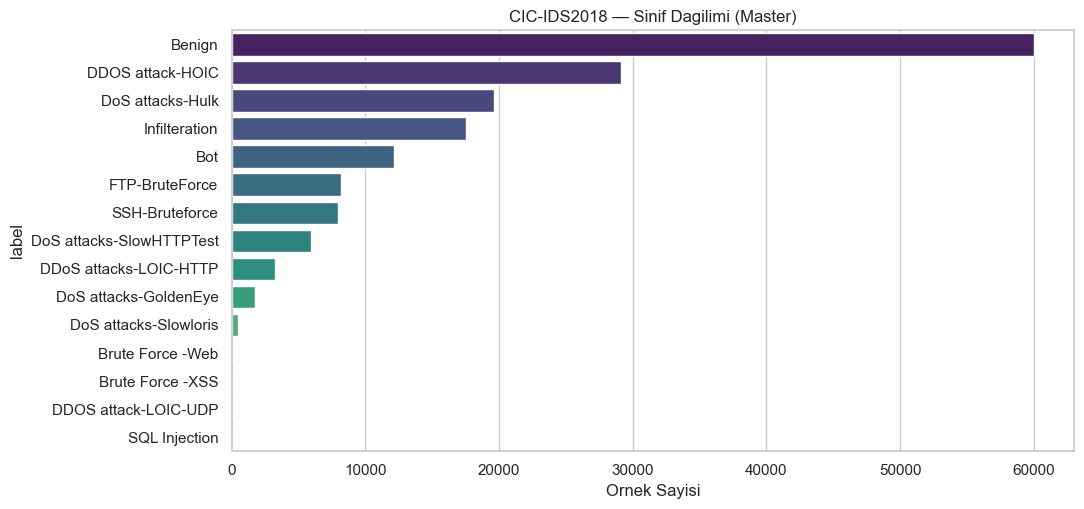

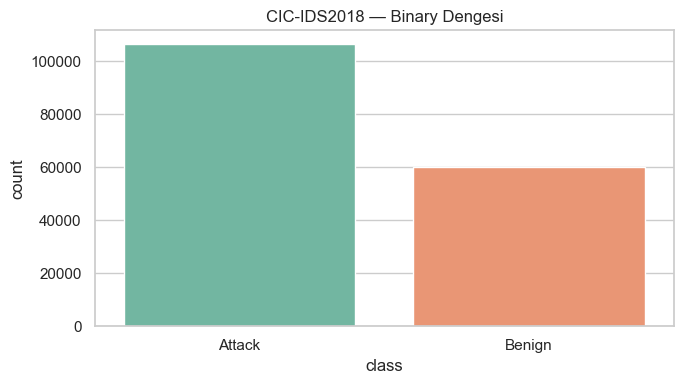

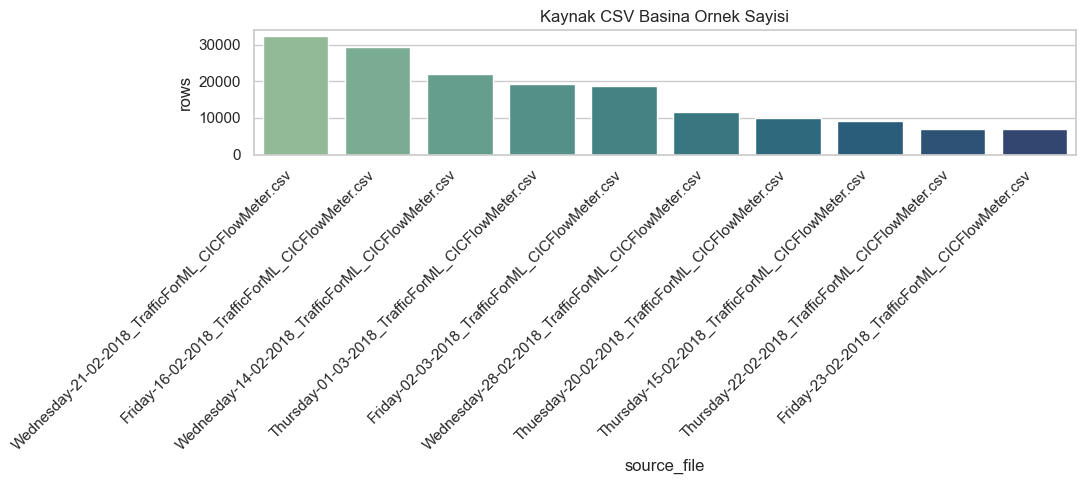

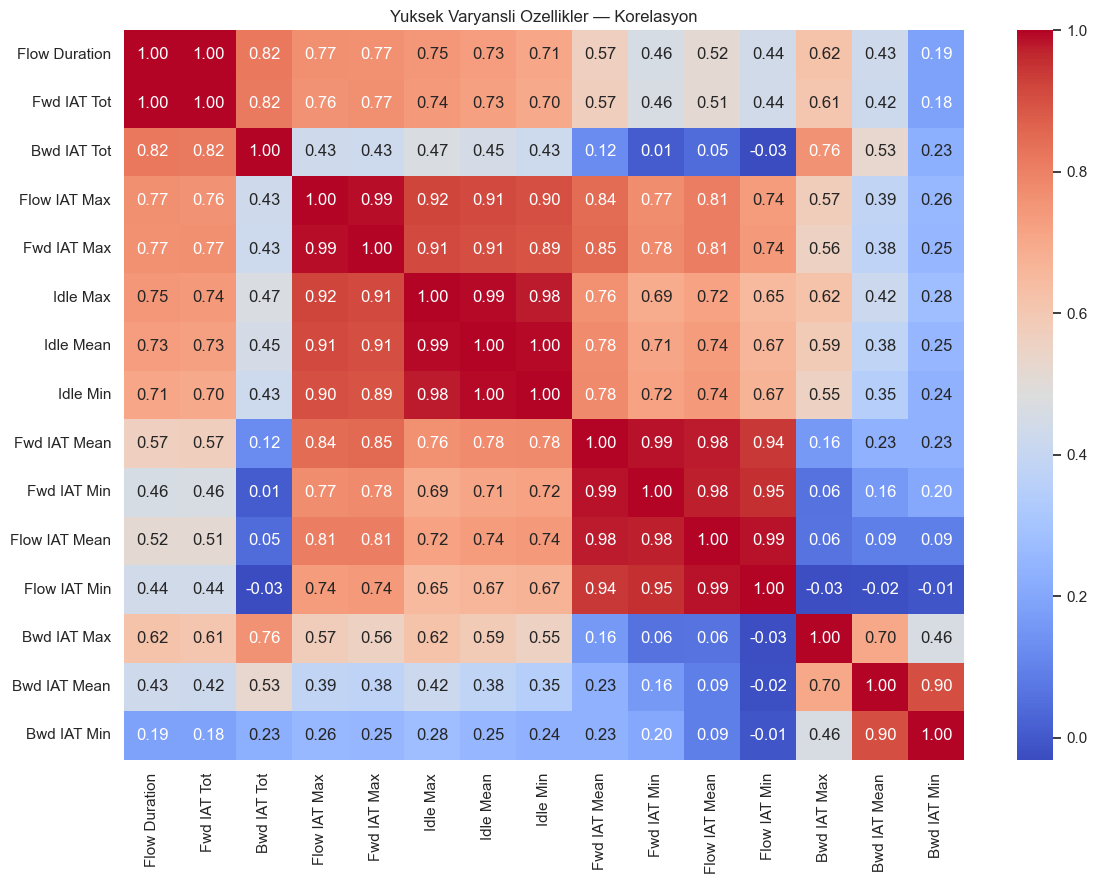

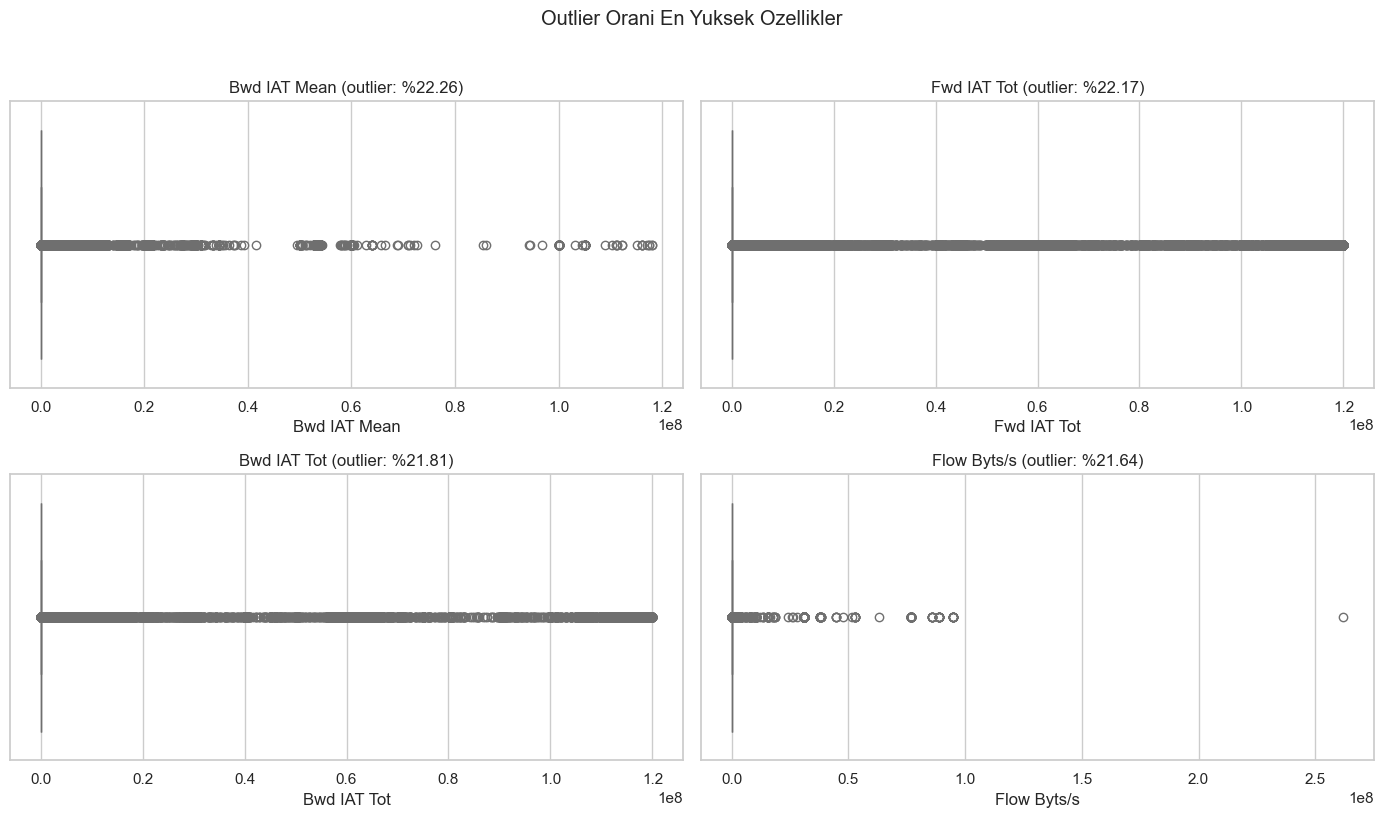

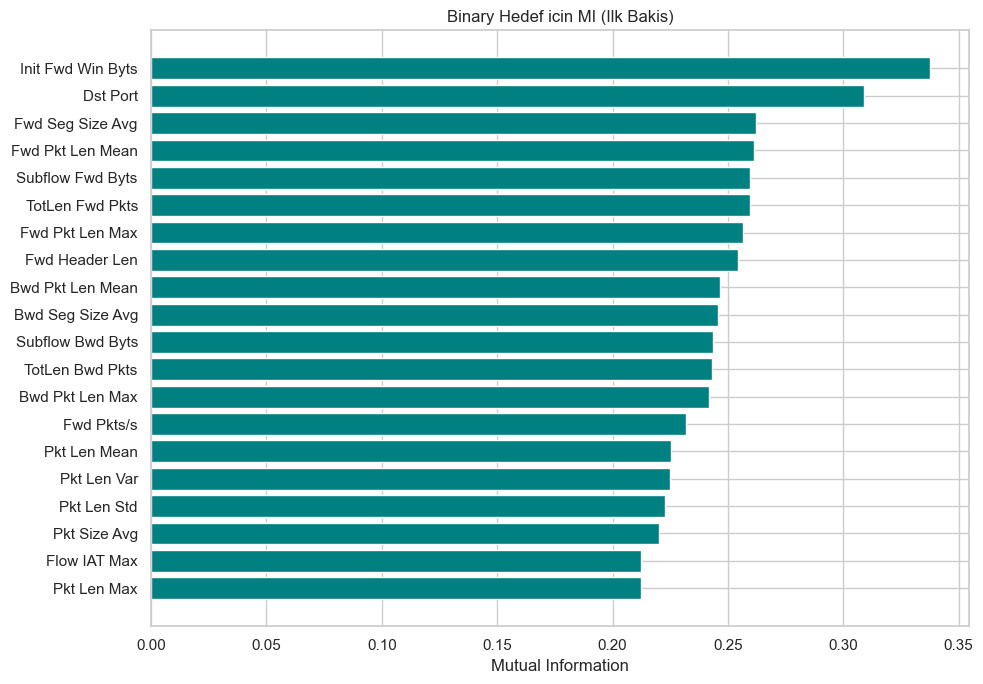

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

_root = None
for _candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_candidate / "configs" / "datasets.yaml").exists():
        _root = _candidate
        break
if _root is None:
    raise FileNotFoundError("Project root bulunamadi.")

_eda_dir = _root / "notebooks" / "eda"
for _path in (str(_root), str(_eda_dir)):
    if _path not in sys.path:
        sys.path.insert(0, _path)

from eda_common import find_project_root, run_cloud_professional_eda

%matplotlib inline
run_cloud_professional_eda(find_project_root(Path.cwd()))
plt.close("all")
